In [2]:
import torchvision
import torchvision.transforms as transforms
import torch
import os
import matplotlib.pyplot as plt
from models import ClassifieurMovie, ClassifieurResNet18, ClassifieurResNet34
from torchvision.datasets.folder import ImageFolder, default_loader, IMG_EXTENSIONS 
from torch.utils.data import Dataset, DataLoader
from data_utils import ImageAndPathDataset
from PIL import Image
import numpy as np
import torch.nn.functional as F
from lime import lime_image
from skimage.segmentation import mark_boundaries


In [3]:
means, stds = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(means, stds)
])

dataset = ImageFolder('./../MovieGenre/content/sorted_movie_posters_paligema', transform=transform, loader=default_loader)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=4)


In [4]:
model_path = 'weights/movie_net.pth'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ClassifieurMovie()

# Load the model
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu'), weights_only=True))
#model.eval()

model.to(device)


ClassifieurMovie(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
          )
          (2): C

In [5]:
idx = 0

# Explanation with LIME

  0%|          | 0/1000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


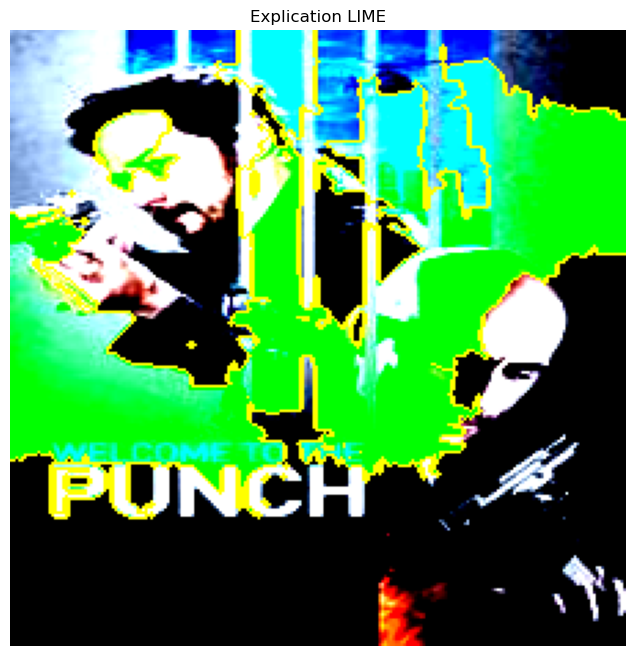

In [6]:


lime_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=means, std=stds),
])

# Récupérer une image depuis ton dataset
np_img = dataset[3][0]  # tensor (C, H, W)
np_img = np_img.numpy().transpose(1, 2, 0)  # (H, W, C) pour LIME

# Fonction prédictive pour LIME
def batch_predict(images):
    batch = []
    for i in images:
        while i.ndim > 3:
            i = i[0]
        if i.dtype != np.uint8:
            i = (i * 255).astype(np.uint8)
        img = Image.fromarray(i)
        img_tensor = lime_transform(img)
        batch.append(img_tensor)
    batch = torch.stack(batch).to(device)
    with torch.no_grad():
        logits = model(batch)
    return F.softmax(logits, dim=1).cpu().numpy()

# Création de l'explainer LIME
explainer = lime_image.LimeImageExplainer()

# Explication
explanation = explainer.explain_instance(
    np_img,
    batch_predict,
    top_labels=5,
    hide_color=0,
    num_samples=1000
)

# Récupérer l'image avec son masque
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],  # label prédominant
    positive_only=False,
    num_features=10,
    hide_rest=False
)

# Affichage
plt.figure(figsize=(8, 8))
plt.imshow(mark_boundaries(temp, mask))
plt.title("Explication LIME")
plt.axis('off')
plt.show()

# Saliency Map

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(-0.5, 223.5, 223.5, -0.5)

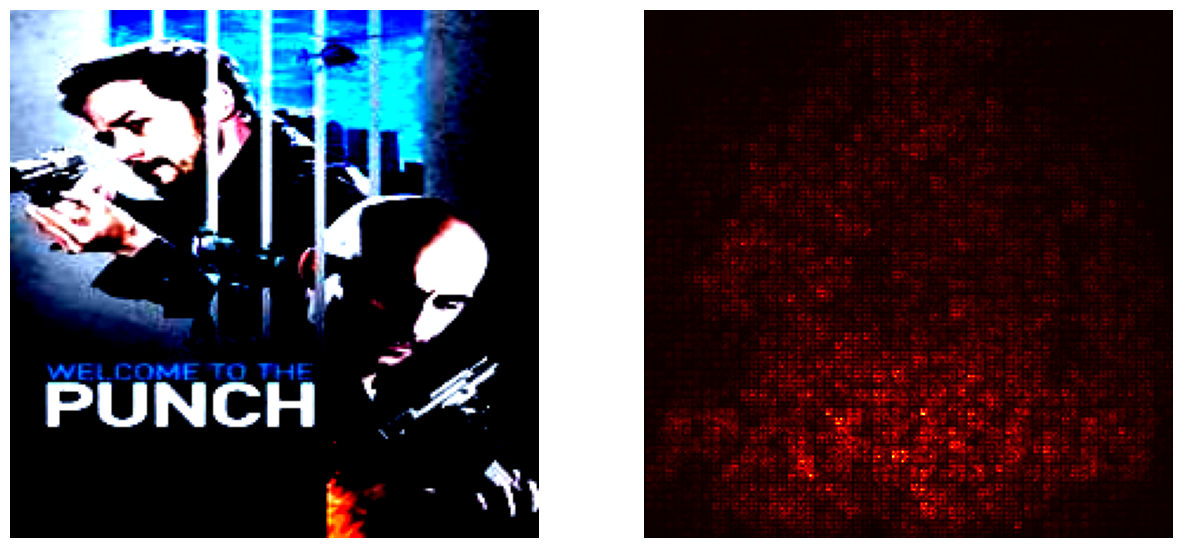

In [7]:
#x, _ = next(iter(dataloader))

#img = x[idx]
img = dataset[idx][0]  # Récupérer l'image du dataset
img = img.unsqueeze(0).to(device)  # Ajouter une dimension batch
img.requires_grad_()

output = model(img)
output_idx = output.argmax()
output_max = output[0, output_idx]

output_max.backward()

saliency, _ = torch.max(img.grad.data.abs(), dim=1)
saliency = saliency.squeeze(0)


plt.figure(figsize=(15,10))
plt.subplot(1,2,1)
plt.imshow(np_img)
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(saliency.cpu(), cmap='hot')
plt.axis('off')

# Smooth Grad

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(-0.5, 223.5, 223.5, -0.5)

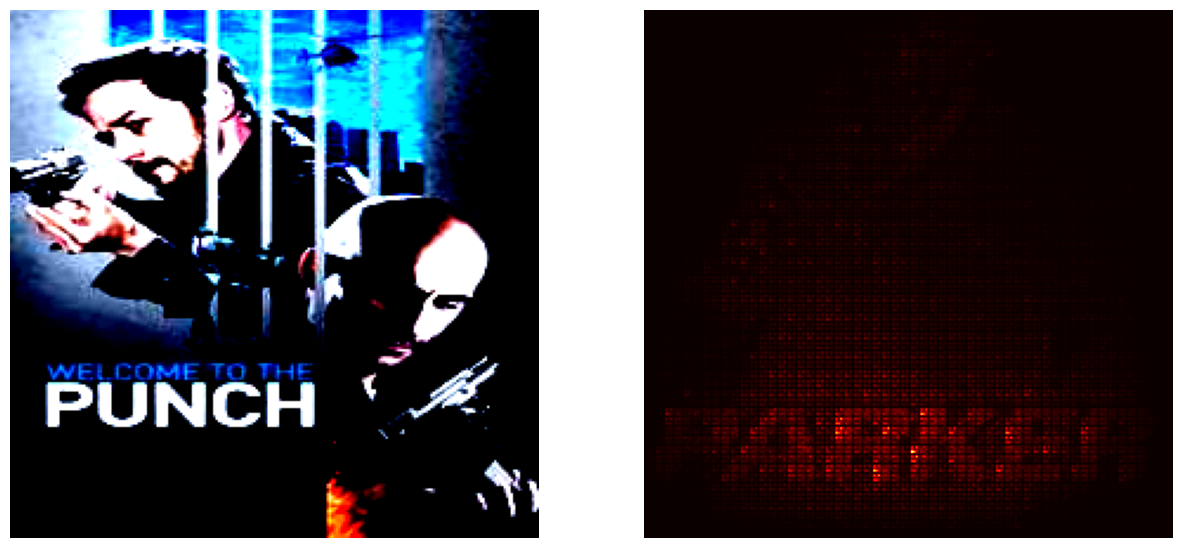

In [8]:
def get_vanilla_grad(img, model):
  #retain gradients
  img.retain_grad()
  output = model(img)
  output_idx = output.argmax()
  output_max = output[0, output_idx]
  output_max.backward()

  return img.grad

stdev_spread=0.15
n_samples=100
stdev = stdev_spread * (img.max() - img.min())
total_gradients = torch.zeros_like(img, device=device)

for i in range(n_samples):
    noise = np.random.normal(0, stdev.item(), img.shape).astype(np.float32)
    noisy_img = img + torch.tensor(noise, device='cuda', requires_grad=True)
    grad= get_vanilla_grad(noisy_img, model)
    total_gradients += grad * grad #using the square of the gradients generates smoother visualizations
    #total_gradients += grad
total_gradients /= n_samples

saliency, _ = torch.max(total_gradients.abs(), dim=1)
saliency = saliency.squeeze(0)


plt.figure(figsize=(15,10))
plt.subplot(1,2,1)
plt.imshow(np_img)
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(saliency.cpu(), cmap='hot')
plt.axis('off')

# Grad-CAM

(-0.5, 223.5, 223.5, -0.5)

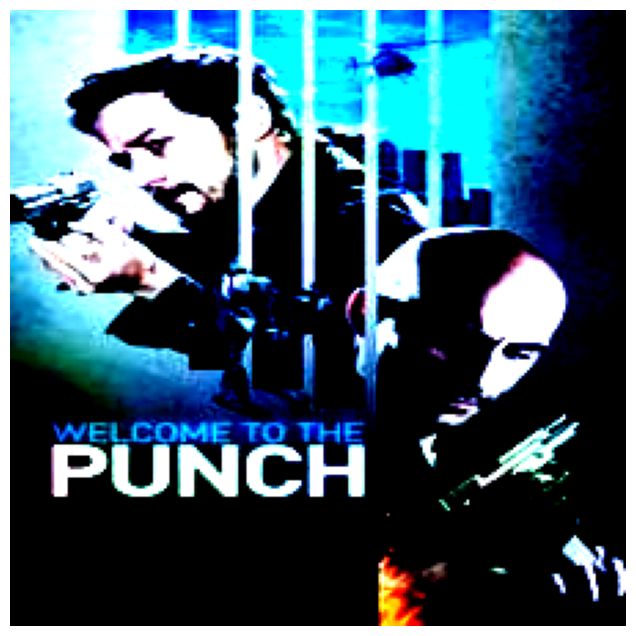

In [9]:
import cv2

class HookFeatures():
    def __init__(self, module):
        self.feature_hook = module.register_forward_hook(self.feature_hook_fn)
    def feature_hook_fn(self, module, input, output):
        self.features = output.clone().detach()
        self.gradient_hook = output.register_hook(self.gradient_hook_fn)
    def gradient_hook_fn(self, grad):
        self.gradients = grad
    def close(self):
        self.feature_hook.remove()
        self.gradient_hook.remove()


hook = HookFeatures(model.features[12])  # Assuming you want to hook the first feature layer

output = model(img)
output_idx = output.argmax()
output_max = output[0, output_idx]
output_max.backward()

gradients = hook.gradients
activations = hook.features
pooled_gradients = torch.mean(gradients, dim=[0, 2, 3]) # we take the average gradient of every chanels
for i in range(activations.shape[1]):
    activations[:, i, :, :] *= pooled_gradients[i] # we multiply every chanels of the feature map with their corresponding averaged gradients

heatmap = torch.mean(activations, dim=1).squeeze()
heatmap = np.maximum(heatmap.detach().cpu(), 0)
heatmap /= torch.max(heatmap)
heatmap = cv2.resize(np.float32(heatmap), (img.shape[2], img.shape[3]))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_RAINBOW) / 255
superposed_img = (heatmap) * 0.4 + np_img
plt.figure(figsize=(8,8))
plt.imshow(np.clip(superposed_img,0,1))
plt.axis('off')

In [10]:
print(model.features)

Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
    (2): Hardswish()
  )
  (1): InvertedResidual(
    (block): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (1): SqueezeExcitation(
        (avgpool): AdaptiveAvgPool2d(output_size=1)
        (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
        (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
        (activation): ReLU()
        (scale_activation): Hardsigmoid()
      )
      (2): Conv2dNormActivation(
        (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, mo